# Week 2 Assignment: Exploratory Data Analysis (EDA) on the Titanic Dataset

This notebook performs a comprehensive EDA on the Titanic dataset to understand survival patterns and prepare the data for further modeling.

**Objective:**
- Load and inspect the dataset.
- Clean and preprocess the data.
- Visualize key trends and features.
- Extract meaningful insights.

## 1. Import Libraries and Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset from seaborn
df = sns.load_dataset('titanic')
print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


> **Insight 1:** The dataset contains information about passengers like age, sex, class, and whether they survived. Notice the `deck` and `embark_town` columns might have missing values.

## 2. Data Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Data Cleaning and Preprocessing

In [6]:
# Filling missing age with median
df['age'] = df['age'].fillna(df['age'].median())

# Filling missing embarked with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Dropping 'deck' due to too many missing values
df.drop(columns=['deck'], inplace=True)

print("Data cleaning complete. Remaining missing values:")
print(df.isnull().sum())

Data cleaning complete. Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


> **Insight 2:** We filled missing `age` values with the median to avoid skewing the distribution. The `deck` column was dropped as over 70% of its data was missing.

## 4. Exploratory Data Analysis (Visualizations)

### 4.1 Survival Rate by Gender

C:\Users\User\AppData\Local\Temp\ipykernel_6624\235618082.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='survived', data=df, palette='viridis')


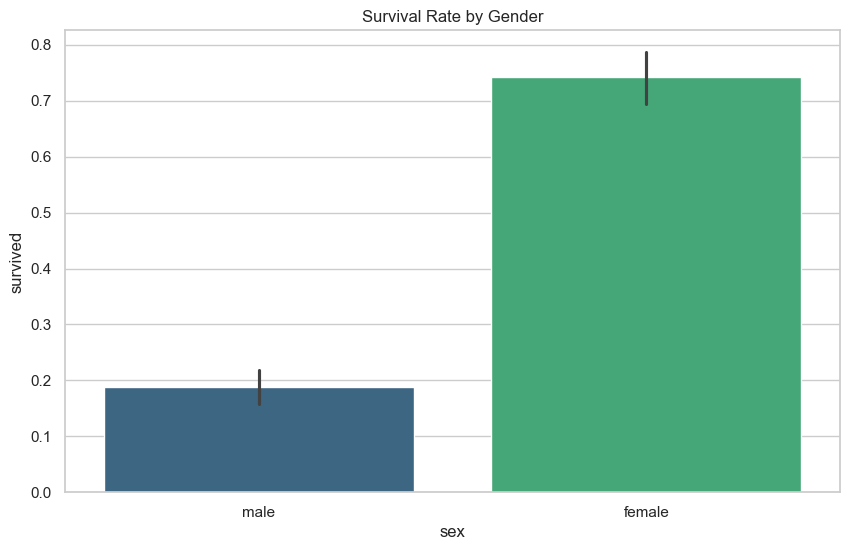

In [7]:
sns.barplot(x='sex', y='survived', data=df, palette='viridis')
plt.title('Survival Rate by Gender')
plt.show()

### 4.2 Survival Rate by Class

C:\Users\User\AppData\Local\Temp\ipykernel_6624\3567748660.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='survived', data=df, palette='magma')


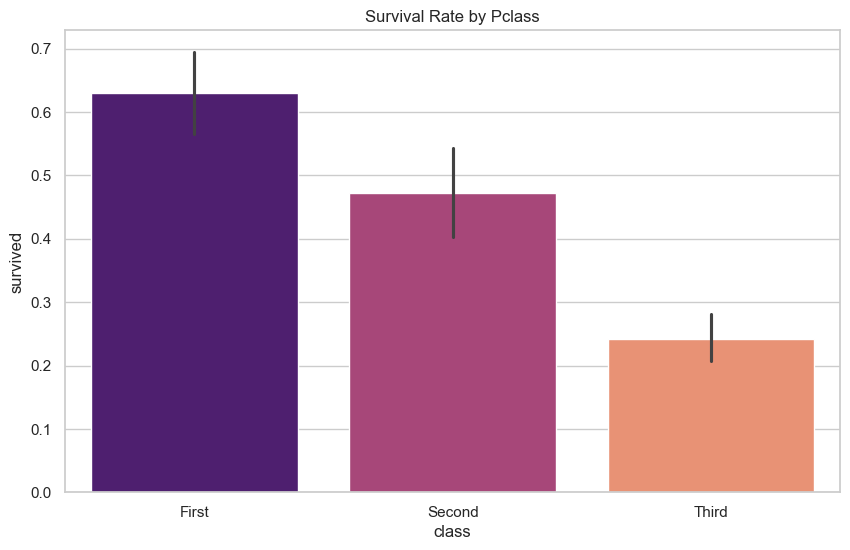

In [8]:
sns.barplot(x='class', y='survived', data=df, palette='magma')
plt.title('Survival Rate by Pclass')
plt.show()

### 4.3 Age Distribution of Survivors vs Non-Survivors

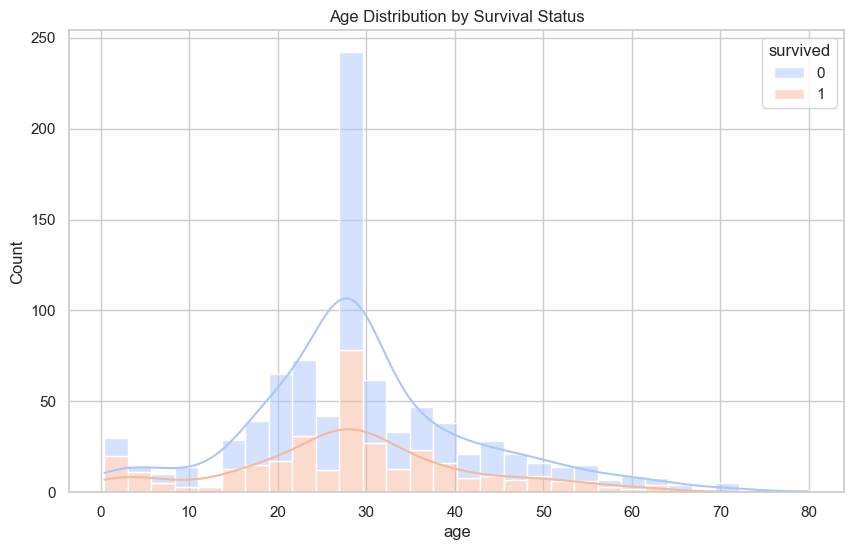

In [9]:
sns.histplot(data=df, x='age', hue='survived', multiple='stack', kde=True, palette='coolwarm')
plt.title('Age Distribution by Survival Status')
plt.show()

### 4.4 Correlation Heatmap

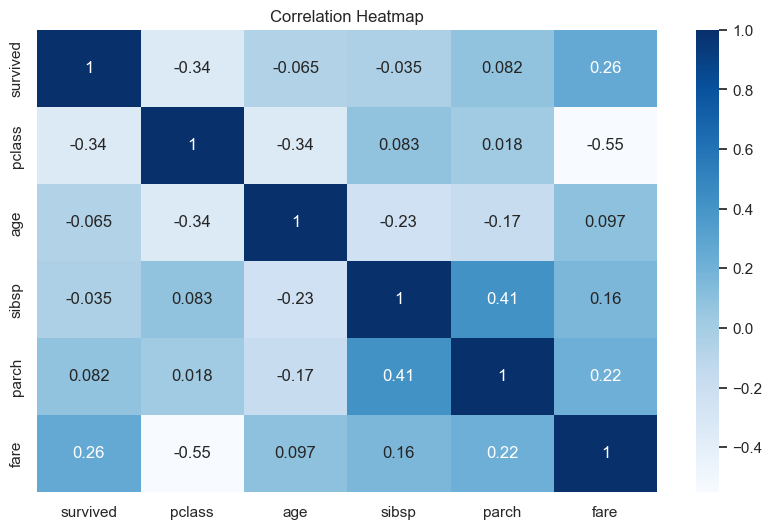

In [10]:
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

## 5. Summary and Key Insights

1. **Gender Bias in Survival:** Females had a significantly higher survival rate compared to males, consistent with the "women and children first" protocol.
2. **Class Matters:** Passengers in the 1st class (First) had the highest survival probability, while those in the 3rd class had the lowest.
3. **Age Impact:** Children (low age) showed a relatively higher survival rate, while the majority of non-survivors were adults between 20-40.